# 02_EDA_LinkedIn


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

## Load Datasets

In [2]:
linkedin = pd.read_csv('linkedin_job_postings.csv')
job_skills = pd.read_csv('job_skills.csv')
job_summary = pd.read_csv('job_summary.csv')

postings = pd.read_csv('postings.csv')
job_skills_map = pd.read_csv('job_skills_1.csv')
skills = pd.read_csv('skills_1.csv')

job_industries = pd.read_csv('job_industries.csv')
industries = pd.read_csv('industries.csv')

companies = pd.read_csv('companies.csv')
salaries = pd.read_csv('salaries.csv')


## Dataset Overview

In [3]:
datasets = {
    'linkedin': linkedin,
    'job_skills': job_skills,
    'postings': postings,
    'companies': companies,
    'salaries': salaries
}

for name, df in datasets.items():
    print('='*60)
    print(name)
    print('Shape:', df.shape)
    display(df.head())


linkedin
Shape: (1348454, 14)


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite


job_skills
Shape: (1296381, 2)


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."


postings
Shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


companies
Shape: (24473, 10)


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


salaries
Shape: (40785, 8)


,salary_id,job_id,max_salary,med_salary,min_salary,pay_period,currency,compensation_type
0,1,3884428798,NaN,20.0,NaN,HOURLY,USD,BASE_SALARY
1,2,3887470552,25.0,NaN,23.0,HOURLY,USD,BASE_SALARY
2,3,3884431523,120000.0,NaN,100000.0,YEARLY,USD,BASE_SALARY
3,4,3884911725,200000.0,NaN,10000.0,YEARLY,USD,BASE_SALARY
4,5,3887473220,35.0,NaN,33.0,HOURLY,USD,BASE_SALARY


## Missing Value Analysis

In [4]:
for name, df in datasets.items():
    print('\n', name)
    display((df.isnull().sum()/len(df)*100).sort_values(ascending=False).head(15))



 linkedin


job_location           0.001409
company                0.000816
got_summary            0.000000
got_ner                0.000000
job_link               0.000000
last_processed_time    0.000000
job_title              0.000000
is_being_worked        0.000000
first_seen             0.000000
search_city            0.000000
search_country         0.000000
search_position        0.000000
job_level              0.000000
job_type               0.000000
dtype: float64


 job_skills


job_skills    0.160832
job_link      0.000000
dtype: float64


 postings


closed_time                   99.133622
skills_desc                   98.030666
med_salary                    94.929309
remote_allowed                87.689848
applies                       81.170619
min_salary                    75.944093
max_salary                    75.944093
currency                      70.873402
compensation_type             70.873402
pay_period                    70.873402
normalized_salary             70.873402
posting_domain                32.271556
application_url               29.604599
formatted_experience_level    23.745852
fips                          22.135827
dtype: float64


 companies


company_size    11.334941
description      1.213582
zip_code         0.114412
state            0.089895
address          0.089895
name             0.004086
city             0.004086
company_id       0.000000
country          0.000000
url              0.000000
dtype: float64


 salaries


med_salary           83.234032
max_salary           16.765968
min_salary           16.765968
job_id                0.000000
salary_id             0.000000
pay_period            0.000000
currency              0.000000
compensation_type     0.000000
dtype: float64

## Top Job Titles

job_title
LEAD SALES ASSOCIATE-FT                                7325
Shift Manager                                          5818
First Year Tax Professional                            5356
Assistant Manager                                      5346
Customer Service Representative                        5203
LEAD SALES ASSOCIATE-PT                                4924
Store Manager                                          4791
CUSTOMER SERVICE REPRESENTATIVE                        4218
Registered Nurse                                       4190
Hourly Supervisor & Training                           2955
Travel Allied Health Professional - CT Technologist    2933
Host                                                   2871
Account Executive                                      2631
Senior Accountant                                      2548
Restaurant Manager                                     2335
Hourly Supervisor and Training                         2230
Veterinarian                  

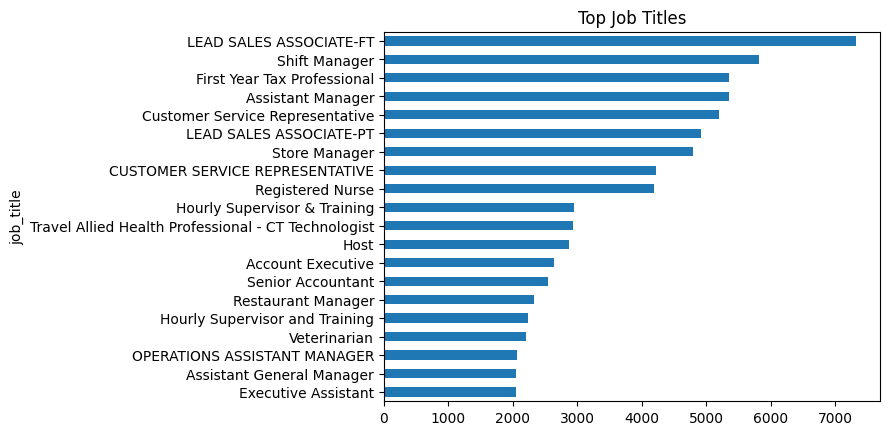

In [5]:
top_titles = linkedin['job_title'].value_counts().head(20)
display(top_titles)

top_titles.sort_values().plot(kind='barh')
plt.title('Top Job Titles')
plt.show()


## Job Levels

In [6]:
linkedin['job_level'].value_counts()

job_level
Mid senior    1204445
Associate      144009
Name: count, dtype: int64

## Job Types

In [7]:
linkedin['job_type'].value_counts()

job_type
Onsite    1337633
Hybrid       6562
Remote       4259
Name: count, dtype: int64

## Geographic Analysis

In [8]:
linkedin['search_country'].value_counts().head(20)

search_country
United States     1149342
United Kingdom     113421
Canada              55972
Australia           29719
Name: count, dtype: int64

In [9]:
linkedin['search_city'].value_counts().head(20)

search_city
Baytown              10052
North Carolina       10015
Garland               9739
Greater London        9297
Austin                8897
South Carolina        8386
Sarnia-Clearwater     7887
Atlanta               7666
Indiana               7599
Alabama               7575
Hollywood             7398
Norristown            7377
Alexandria            7324
Santa Clara           7316
Chicago               7299
Glendale              7244
Pasadena              7181
Avondale              7153
Wisconsin             7073
San Antonio           6725
Name: count, dtype: int64

## Company Analysis

In [10]:
linkedin['company'].value_counts().head(20)

company
Health eCareers                        41598
Jobs for Humanity                      27680
TravelNurseSource                      16142
Dollar General                         14815
PracticeLink                            9738
Energy Jobline                          9365
Gotham Enterprises Ltd                  8935
Jobot                                   8713
ClearanceJobs                           8599
McDonald's                              8125
VolunteerMatch                          6834
Walmart                                 6629
DocCafe                                 6106
H&R Block                               5697
Circle K                                5572
ClickJobs.io                            5570
CyberCoders                             5401
Michael Page                            4737
U.S. Department of Veterans Affairs     4564
BCG Attorney Search                     4558
Name: count, dtype: int64

In [11]:
companies['country'].value_counts().head(20)

country
US    21635
0       727
GB      620
CA      258
IN      157
DE      128
FR      118
CH       93
AU       73
NL       64
SE       48
CN       47
IT       46
DK       42
ES       31
SG       30
BE       29
IE       28
JP       23
IL       21
Name: count, dtype: int64

## Industry Analysis

In [12]:
industry_df = job_industries.merge(industries,on='industry_id')
industry_df['industry_name'].value_counts().head(20)


industry_name
Hospitals and Health Care             18326
Retail                                11033
IT Services and IT Consulting         10396
Staffing and Recruiting                9005
Financial Services                     8535
Software Development                   5091
Manufacturing                          3689
Construction                           3445
Banking                                2923
Insurance                              2673
Pharmaceutical Manufacturing           2469
Hospitality                            2455
Telecommunications                     2433
Real Estate                            2326
Industrial Machinery Manufacturing     2143
Non-profit Organizations               2063
Biotechnology Research                 2005
Accounting                             1968
Motor Vehicle Manufacturing            1951
Food and Beverage Services             1880
Name: count, dtype: int64

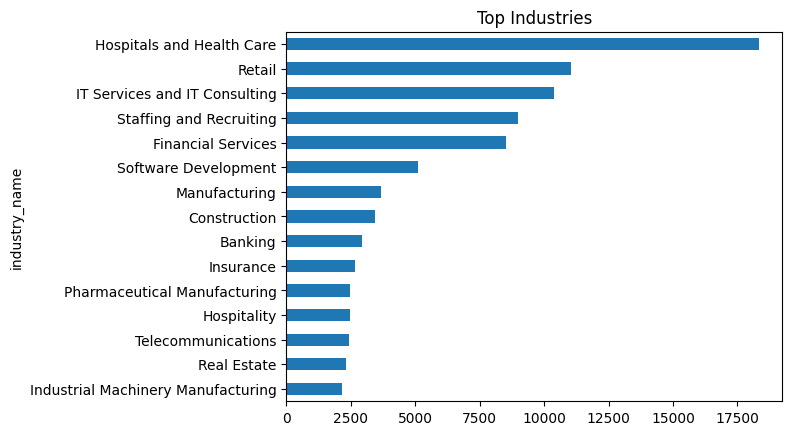

In [13]:
industry_df['industry_name'].value_counts().head(15).sort_values().plot(kind='barh')
plt.title('Top Industries')
plt.show()


## Skill Analysis

In [14]:
all_skills = []

for row in job_skills['job_skills'].dropna():
    skills_list = str(row).split(',')
    all_skills.extend([x.strip() for x in skills_list])

skills_df = pd.Series(all_skills)
skills_df.value_counts().head(30)


Communication             368293
Teamwork                  226266
Leadership                184341
Customer service          166209
Communication skills      116260
Customer Service          110418
Problem Solving           102046
Sales                      92766
Problemsolving             92512
Nursing                    87484
Collaboration              86804
Training                   83195
Project Management         81106
Communication Skills       78721
Attention to detail        75476
Microsoft Office Suite     73372
Time management            72481
Time Management            69769
Scheduling                 64090
Microsoft Office           60277
Multitasking               59234
Adaptability               58707
Patient Care               58373
Attention to Detail        57676
Flexibility                56556
Interpersonal skills       55553
Documentation              51511
Data Analysis              47366
Organization               46853
Problem solving            46221
Name: coun

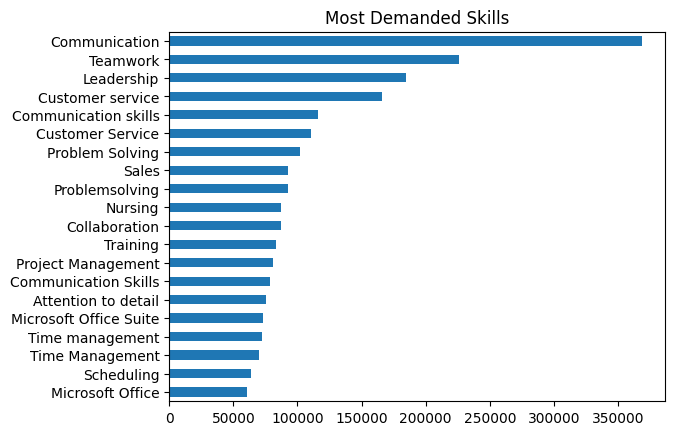

In [15]:
skills_df.value_counts().head(20).sort_values().plot(kind='barh')
plt.title('Most Demanded Skills')
plt.show()


## Standardized Skill Analysis

In [16]:
skill_map = job_skills_map.merge(skills,on='skill_abr')
skill_map['skill_name'].value_counts().head(30)


skill_name
Information Technology    26137
Sales                     22475
Management                20861
Manufacturing             18185
Health Care Provider      17369
Business Development      14290
Engineering               13009
Other                     12608
Finance                    8540
Marketing                  5525
Accounting/Auditing        5461
Administrative             4860
Customer Service           4292
Project Management         3997
Analyst                    3858
Research                   2986
Human Resources            2647
Legal                      2371
Consulting                 2338
Education                  2290
Design                     2244
Training                   2243
General Business           1984
Quality Assurance          1791
Art/Creative               1664
Writing/Editing            1443
Product Management         1362
Public Relations           1298
Supply Chain               1180
Strategy/Planning          1178
Name: count, dtype: int64

## Salary Analysis

In [17]:
salaries['med_salary'].describe()

count      6838.000000
mean      21370.298197
std       51338.564166
min           0.000000
25%          18.500000
50%          25.000000
75%        2207.000000
max      750000.000000
Name: med_salary, dtype: float64

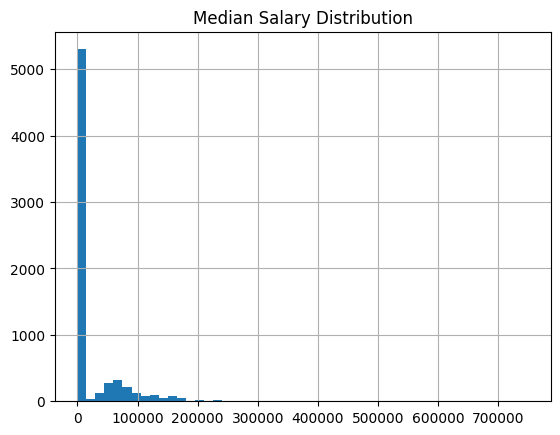

In [20]:
salaries['med_salary'].dropna().hist(bins=50)
plt.title('Median Salary Distribution')
plt.show()


In [26]:
salary_jobs = salaries.merge(
    postings,
    on='job_id',
    suffixes=('_salary', '_posting')
)

salary_jobs.groupby('title')['med_salary_salary'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(20)


title
Oral Surgeon - DDS/DMD                                                               750000.0
Senior Sales Account Executive - Enterprise                                          750000.0
Orthopedic Surgeon                                                                   680000.0
Hematology / Oncology                                                                550000.0
Non-Invasive Cardiology Physician                                                    541000.0
Stanford Cardiology, Electrophysiology                                               525000.0
Regional Director Design - Architecture                                              500000.0
Physician - ENT-Otolaryngology                                                       500000.0
Anesthesiologist                                                                     500000.0
Underwriting Technician, National Accounts Casualty                                  500000.0
Otorhinolaryngologist                                 

## Remote Work Analysis

In [22]:
postings['remote_allowed'].value_counts()

remote_allowed
1.0    15246
Name: count, dtype: int64

## Experience Level Analysis

In [23]:
postings['formatted_experience_level'].value_counts()

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

## Most Viewed Jobs

In [24]:
postings[['title','views']].sort_values('views',ascending=False).head(20)

,title,views
89117,Senior Business Operations Manager,9975.0
14649,Executive Administrative Assistant,9949.0
93,Executive Assistant,8062.0
88474,Executive Assistant,6105.0
89356,Customer Success Manager,5518.0
88826,Supply Chain Analyst,5132.0
88164,Executive Assistant CPO,4951.0
87554,"VP, Health Plan Account Management",4807.0
8189,Customer Operations - Talent Community,4753.0
65991,Social Media Manager,4378.0


## Final Insights

In [25]:
print('Top Skill:', skills_df.value_counts().idxmax())
print('Top Country:', linkedin['search_country'].mode()[0])
print('Top Industry:', industry_df['industry_name'].mode()[0])
print('Most Common Job Title:', linkedin['job_title'].mode()[0])


Top Skill: Communication
Top Country: United States
Top Industry: Hospitals and Health Care
Most Common Job Title: LEAD SALES ASSOCIATE-FT
